In [4]:
# ✅ Cell 1 — Install
!pip install ultralytics fiftyone

# ✅ Cell 2 — Download Open Images Vehicle Dataset via FiftyOne
import fiftyone as fo
import fiftyone.zoo as foz

dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="train",
    label_types=["detections"],
    classes=["Car", "Truck", "Bus", "Motorcycle", "Bicycle"],
    max_samples=300       # keep it small so it downloads fast
)

export_dir = "dataset/train"

dataset.export(
    export_dir=export_dir,
    dataset_type=fo.types.YOLOv5Dataset,
    label_field="ground_truth",
)

print("Dataset ready!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.6/934.6 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 17.6 MB/s eta 

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v7/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v7/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [15.4s elapsed, 0s remaining, 337.5Mb/s]      


...

Dataset 'open-images-v7-train-300' created


INFO:fiftyone.zoo.datasets:Dataset 'open-images-v7-train-300' created


 100% |█████████████████| 300/300 [2.5s elapsed, 0s remaining, 136.3 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 300/300 [2.5s elapsed, 0s remaining, 136.3 samples/s]      


Dataset ready!


In [5]:
# ✅ Cell 3 — Create data.yaml
data_yaml = """
path: dataset
train: train/images
val: train/images

names:
  0: Car
  1: Truck
  2: Bus
  3: Motorcycle
  4: Bicycle
"""

with open("dataset/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created")

data.yaml created


In [6]:
# ✅ Cell 4 — Train
import torch
from ultralytics import YOLO

print("GPU Available:", torch.cuda.is_available())

model = YOLO("yolov8n.pt")

model.train(
    data="dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device=0 if torch.cuda.is_available() else "cpu"
)

GPU Available: True
Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b143fbea720>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

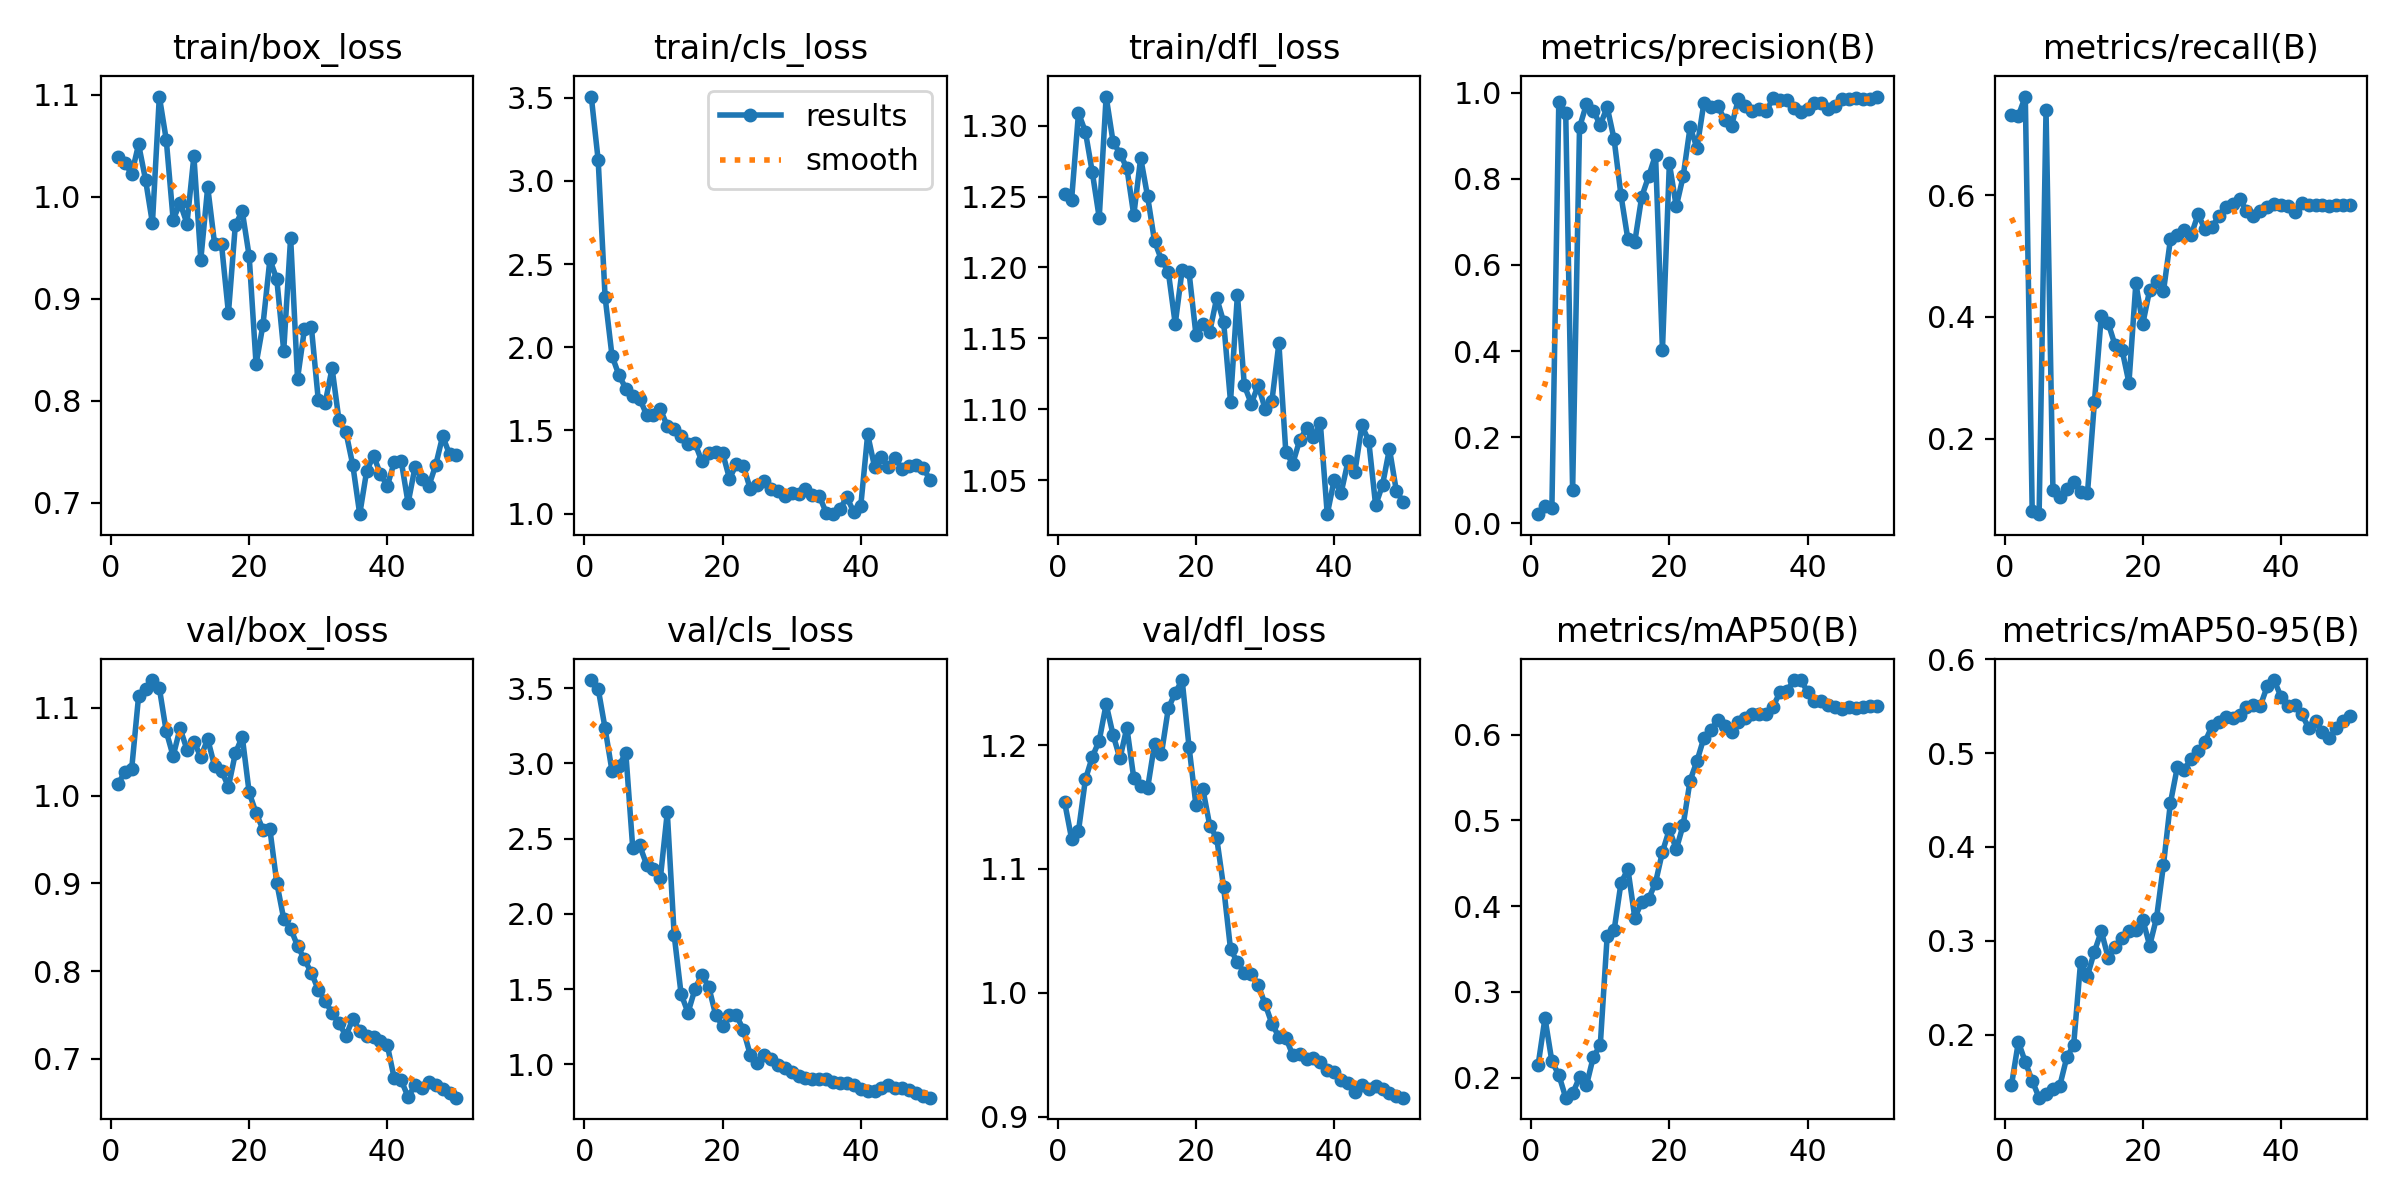

In [7]:
# ✅ Cell 5 — Training results
from IPython.display import Image as IPImage
IPImage("runs/detect/train/results.png")

Upload a road/traffic image to test:


Saving download (1).jpg to download (1).jpg

image 1/1 /content/download (1).jpg: 448x640 7 Trucks, 6.3ms
Speed: 1.6ms preprocess, 6.3ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


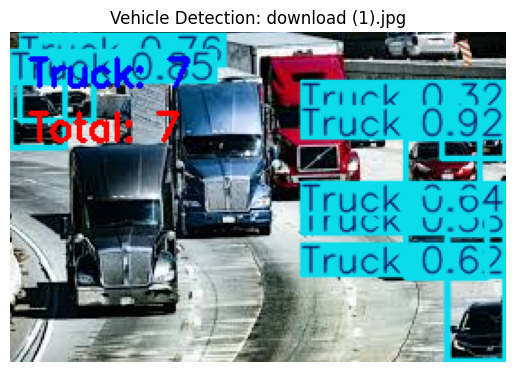


Detection Summary:
  Truck: 7
  Total: 7


In [10]:
# ✅ Cell 6 — Upload YOUR image and test
from google.colab import files
import cv2
import matplotlib.pyplot as plt

print("Upload a road/traffic image to test:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

model = YOLO("runs/detect/train/weights/best.pt")
results = model(filename, conf=0.3)

for r in results:
    img = r.plot()

    boxes = r.boxes
    class_ids = boxes.cls.tolist()
    names = model.names

    counts = {}
    for cls_id in class_ids:
        cls_name = names[int(cls_id)]
        counts[cls_name] = counts.get(cls_name, 0) + 1

    y_offset = 30
    for k, v in counts.items():
        cv2.putText(img, f"{k}: {v}", (10, y_offset),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        y_offset += 30

    cv2.putText(img, f"Total: {len(class_ids)}", (10, y_offset),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Vehicle Detection: {filename}")
    plt.show()

    print("\nDetection Summary:")
    for k, v in counts.items():
        print(f"  {k}: {v}")
    print(f"  Total: {len(class_ids)}")